# Customer Churn Prediction

Predicting whether a telecom customer will churn (leave the service) using the Telco Customer Churn dataset from Kaggle.

**Dataset:** 7,043 customers with 21 features including tenure, contract type, monthly charges, and various service subscriptions.

**Approach:** Start with logistic regression as a baseline, then try XGBoost and a neural network. Since churners are the minority class (~26%), we'll use class weight balancing and focus on F1-score rather than just accuracy.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    accuracy_score, precision_score, recall_score
)
from sklearn.utils.class_weight import compute_class_weight

import xgboost as xgb

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

import shap

warnings.filterwarnings('ignore')

## 1. Data Loading & Exploration

In [4]:
df = pd.read_csv('../WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Dataset: 7043 rows, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# check data types and unique values
for col in df.columns:
    print(f"  {col:<25} {str(df[col].dtype):<10} ({df[col].nunique()} unique)")

print(f"\nMissing values: {df.isnull().sum().sum()}")
# note: TotalCharges looks like object dtype which is suspicious
df.describe()

  customerID                object     (7043 unique)
  gender                    object     (2 unique)
  SeniorCitizen             int64      (2 unique)
  Partner                   object     (2 unique)
  Dependents                object     (2 unique)
  tenure                    int64      (73 unique)
  PhoneService              object     (2 unique)
  MultipleLines             object     (3 unique)
  InternetService           object     (3 unique)
  OnlineSecurity            object     (3 unique)
  OnlineBackup              object     (3 unique)
  DeviceProtection          object     (3 unique)
  TechSupport               object     (3 unique)
  StreamingTV               object     (3 unique)
  StreamingMovies           object     (3 unique)
  Contract                  object     (3 unique)
  PaperlessBilling          object     (2 unique)
  PaymentMethod             object     (4 unique)
  MonthlyCharges            float64    (1585 unique)
  TotalCharges              object     (653

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 2. Data Cleaning

In [6]:
# customerID is just an identifier, not useful for prediction
df = df.drop('customerID', axis=1)

# TotalCharges has some blank strings that got read as object type
# convert to numeric and fill the resulting NaNs with the median
print(f"TotalCharges dtype before: {df['TotalCharges'].dtype}")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
n_missing = df['TotalCharges'].isnull().sum()
print(f"Found {n_missing} invalid entries in TotalCharges")

median_tc = df['TotalCharges'].median()
df['TotalCharges'] = df['TotalCharges'].fillna(median_tc)
print(f"Filled with median: ${median_tc:.2f}")

# SeniorCitizen is 0/1 but it's really categorical
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# create numeric target
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f"\nCleaned dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Churn distribution:")
print(f"  Not Churned: {(df['Churn_Binary']==0).sum()} ({(df['Churn_Binary']==0).mean():.1%})")
print(f"  Churned:     {(df['Churn_Binary']==1).sum()} ({(df['Churn_Binary']==1).mean():.1%})")

TotalCharges dtype before: object
Found 11 invalid entries in TotalCharges
Filled with median: $1397.47

Cleaned dataset: 7043 rows, 21 columns
Churn distribution:
  Not Churned: 5174 (73.5%)
  Churned:     1869 (26.5%)


So about 26.5% of customers churned. That's a decent amount of imbalance — need to handle this during modeling.

## 3. Exploratory Data Analysis

### 3.1 Churn Distribution

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/eda_plots/churn_distribution.png'

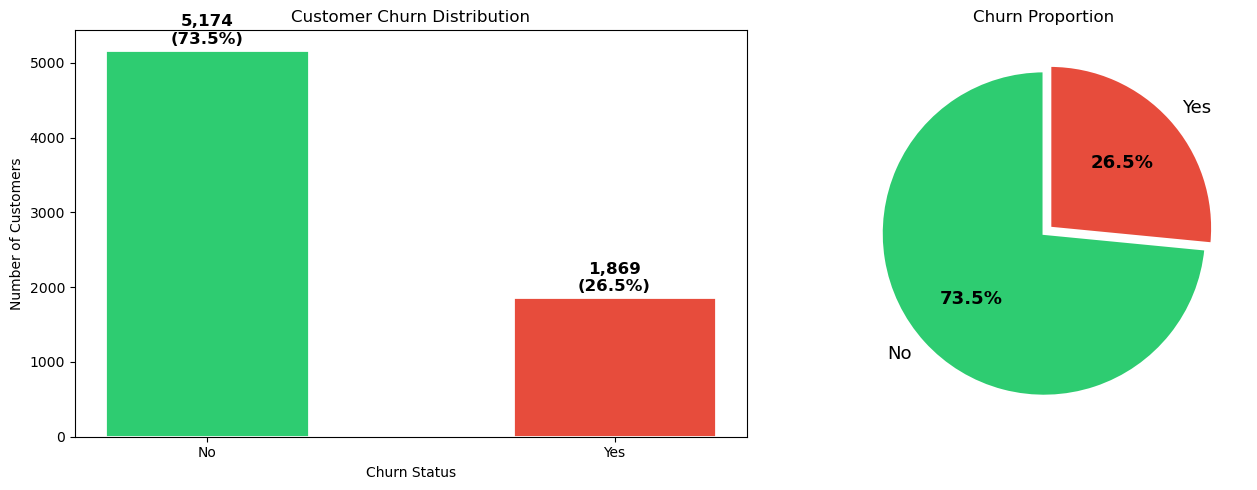

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#e74c3c']
churn_counts = df['Churn'].value_counts()

# bar chart
bars = axes[0].bar(churn_counts.index, churn_counts.values,
                   color=colors, edgecolor='white', linewidth=2, width=0.5)
axes[0].set_title('Customer Churn Distribution')
axes[0].set_xlabel('Churn Status')
axes[0].set_ylabel('Number of Customers')
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f'{val:,}\n({val/len(df):.1%})', ha='center', fontsize=12, fontweight='bold')

# pie chart
wedges, texts, autotexts = axes[1].pie(
    churn_counts.values, labels=churn_counts.index, autopct='%1.1f%%',
    colors=colors, startangle=90, explode=(0, 0.05),
    textprops={'fontsize': 13}, wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Churn Proportion')

plt.tight_layout()
plt.savefig('outputs/eda_plots/churn_distribution.png')
plt.show()

### 3.2 Churn Rate by Contract Type

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

contract_churn = df.groupby('Contract')['Churn_Binary'].mean().sort_values(ascending=False)
colors_contract = ['#e74c3c', '#f39c12', '#2ecc71']

bars = ax.bar(contract_churn.index, contract_churn.values * 100,
              color=colors_contract, edgecolor='white', linewidth=2, width=0.5)

ax.set_title('Churn Rate by Contract Type')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Churn Rate (%)')

for bar, val in zip(bars, contract_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1%}', ha='center', fontsize=14, fontweight='bold')

# show how many customers in each group
for bar, contract in zip(bars, contract_churn.index):
    count = len(df[df['Contract'] == contract])
    ax.text(bar.get_x() + bar.get_width()/2, 2,
            f'n={count:,}', ha='center', fontsize=10, color='white', fontweight='bold')

ax.set_ylim(0, max(contract_churn.values * 100) + 8)
plt.tight_layout()
plt.savefig('outputs/eda_plots/churn_by_contract.png')
plt.show()

Month-to-month customers churn at roughly 3x the rate of yearly contract customers. Makes sense — there's no commitment keeping them around.

### 3.3 Churn Rate by Tenure

In [ ]:
# group tenure into buckets
bins = [0, 12, 24, 48, 60, 72]
labels = ['0-12', '13-24', '25-48', '49-60', '61-72']
df['tenure_group'] = pd.cut(df['tenure'], bins=bins, labels=labels, include_lowest=True)

fig, ax = plt.subplots(figsize=(10, 6))

tenure_churn = df.groupby('tenure_group', observed=False)['Churn_Binary'].mean()

ax.plot(tenure_churn.index, tenure_churn.values * 100, 'o-',
        color='#e74c3c', linewidth=3, markersize=12,
        markerfacecolor='white', markeredgewidth=3, zorder=5)

ax.fill_between(range(len(tenure_churn)), tenure_churn.values * 100,
                alpha=0.12, color='#e74c3c')

ax.set_title('Churn Rate by Customer Tenure')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Churn Rate (%)')

for i, v in enumerate(tenure_churn.values):
    ax.text(i, v * 100 + 2.5, f'{v:.1%}', ha='center', fontsize=12, fontweight='bold')

ax.set_ylim(0, max(tenure_churn.values * 100) + 12)
plt.tight_layout()
plt.savefig('outputs/eda_plots/churn_by_tenure.png')
plt.show()

New customers (first year) have the highest churn by far. The churn rate drops steadily with tenure — customers who stick around past the first year or two are much more likely to stay. This suggests early customer engagement and onboarding experience matters a lot.

### 3.4 Monthly Charges Distribution

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

for churn_val, color, label in [('No', '#2ecc71', 'Not Churned'), ('Yes', '#e74c3c', 'Churned')]:
    subset = df[df['Churn'] == churn_val]['MonthlyCharges']
    ax.hist(subset, bins=40, alpha=0.55, color=color, label=label, edgecolor='white', linewidth=0.5)
    subset.plot.kde(ax=ax, color=color, linewidth=2.5, label=f'{label} (KDE)')

ax.set_title('Monthly Charges Distribution by Churn Status')
ax.set_xlabel('Monthly Charges ($)')
ax.set_ylabel('Density / Frequency')
ax.legend(fontsize=11)
ax.set_xlim(0, 130)

plt.tight_layout()
plt.savefig('outputs/eda_plots/monthly_charges_dist.png')
plt.show()

Churned customers tend to be on higher monthly plans. Customers paying less (~$20/month range) mostly stay, probably because they're on basic plans with fewer alternatives.

### 3.5 Correlation Heatmap

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

numerical_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numerical_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdYlBu_r', center=0,
            fmt='.2f', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Correlation Coefficient'},
            annot_kws={'size': 12})

ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('outputs/eda_plots/correlation_heatmap.png')
plt.show()

MonthlyCharges and TotalCharges are highly correlated (which makes sense — total is just monthly * time). Both show some correlation with churn.

### 3.6 Service Usage vs Churn

In [ ]:
services = ['PhoneService', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, service in enumerate(services):
    churn_rate = df.groupby(service)['Churn_Binary'].mean().sort_values(ascending=False)
    n_cats = len(churn_rate)
    colors_svc = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, n_cats))

    bars = axes[i].bar(range(n_cats), churn_rate.values * 100,
                       color=colors_svc, edgecolor='white', linewidth=1.5)
    axes[i].set_title(service, fontsize=13, fontweight='bold')
    axes[i].set_xticks(range(n_cats))
    axes[i].set_xticklabels(churn_rate.index, rotation=30, ha='right', fontsize=9)
    axes[i].set_ylabel('Churn %', fontsize=10)

    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                     f'{val:.0%}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Churn Rate by Service Type', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/eda_plots/service_usage_churn.png')
plt.show()

Couple of interesting things here:
- Fiber optic internet customers churn way more than DSL customers. Could be price related (fiber is more expensive) or maybe service quality issues.
- Customers without tech support or online security churn a lot more. These services might act as "stickiness" factors that keep people around.

## 4. Feature Engineering & Encoding

In [ ]:
# drop the text version of churn and tenure groups (we have the binary version)
df_model = df.drop(['Churn', 'tenure_group'], axis=1)

X = df_model.drop('Churn_Binary', axis=1)
y = df_model['Churn_Binary']

# one-hot encode all categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f"  {col}: {X[col].unique().tolist()}")

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print(f"\nAfter encoding: {X.shape[1]} features")

# scale the numerical columns
scaler = StandardScaler()
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
X[numerical_features] = scaler.fit_transform(X[numerical_features])

# 80/20 split, stratified to keep the same churn ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples")
print(f"Train churn rate: {y_train.mean():.2%}")
print(f"Test churn rate:  {y_test.mean():.2%}")
print(f"Features: {X_train.shape[1]}")

## 5. Model Training

Training three models with increasing complexity. All use class weight balancing since we have ~26.5% churners vs ~73.5% non-churners.

### 5.1 Logistic Regression

In [ ]:
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    C=0.5,
    solver='lbfgs'
)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
lr_pred_proba = lr_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Results")
print(classification_report(y_test, lr_pred, target_names=['Not Churned', 'Churned']))

lr_f1 = f1_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_pred_proba)
lr_acc = accuracy_score(y_test, lr_pred)
print(f"Accuracy: {lr_acc:.4f}")
print(f"F1 (Churned): {lr_f1:.4f}")
print(f"AUC-ROC: {lr_auc:.4f}")

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, lr_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'], ax=ax,
            annot_kws={'size': 16})
ax.set_title('Logistic Regression - Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('outputs/model_results/lr_confusion_matrix.png')
plt.show()

### 5.2 XGBoost

In [ ]:
# for XGBoost, we use scale_pos_weight to handle class imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw = neg_count / pos_count
print(f"Class ratio: {neg_count}:{pos_count}, scale_pos_weight = {spw:.2f}")

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=spw,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train, verbose=False)

xgb_pred = xgb_model.predict(X_test)
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print("\nXGBoost Results")
print(classification_report(y_test, xgb_pred, target_names=['Not Churned', 'Churned']))

xgb_f1 = f1_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_pred_proba)
xgb_acc = accuracy_score(y_test, xgb_pred)
print(f"Accuracy: {xgb_acc:.4f}")
print(f"F1 (Churned): {xgb_f1:.4f}")
print(f"AUC-ROC: {xgb_auc:.4f}")

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, xgb_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'], ax=ax,
            annot_kws={'size': 16})
ax.set_title('XGBoost - Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('outputs/model_results/xgb_confusion_matrix.png')
plt.show()

In [ ]:
# feature importance from XGBoost
fig, ax = plt.subplots(figsize=(10, 8))

feature_importance = pd.Series(xgb_model.feature_importances_, index=X.columns)
top_features = feature_importance.nlargest(15)

top_features.sort_values().plot(kind='barh', color='#e67e22',
                                edgecolor='white', linewidth=1.5, ax=ax)
ax.set_title('Top 15 Feature Importances (XGBoost)')
ax.set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('outputs/model_results/xgb_feature_importance.png')
plt.show()

print("Top 5 features:")
for i, (feat, imp) in enumerate(top_features.head().items(), 1):
    print(f"  {i}. {feat}: {imp:.4f}")

### 5.3 Neural Network (MLP)

In [ ]:
# compute class weights for the neural net
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes.astype(int), class_weights))
print(f"Class weights: {class_weight_dict}")

input_dim = X_train.shape[1]

mlp_model = Sequential([
    Dense(128, activation='relu', input_dim=input_dim),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
])

mlp_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

mlp_model.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = mlp_model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

In [ ]:
# training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2, color='#3498db')
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2, color='#e74c3c')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2, color='#3498db')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2, color='#e74c3c')
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/model_results/mlp_training_history.png')
plt.show()

n_epochs = len(history.history['loss'])
print(f"Training stopped at epoch {n_epochs}")
print(f"Final train loss: {history.history['loss'][-1]:.4f}")
print(f"Final val loss:   {history.history['val_loss'][-1]:.4f}")

In [ ]:
# evaluate MLP
mlp_pred_proba = mlp_model.predict(X_test, verbose=0).flatten()
mlp_pred = (mlp_pred_proba >= 0.5).astype(int)

print("Neural Network Results")
print(classification_report(y_test, mlp_pred, target_names=['Not Churned', 'Churned']))

mlp_f1 = f1_score(y_test, mlp_pred)
mlp_auc = roc_auc_score(y_test, mlp_pred_proba)
mlp_acc = accuracy_score(y_test, mlp_pred)
print(f"Accuracy: {mlp_acc:.4f}")
print(f"F1 (Churned): {mlp_f1:.4f}")
print(f"AUC-ROC: {mlp_auc:.4f}")

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, mlp_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Not Churned', 'Churned'],
            yticklabels=['Not Churned', 'Churned'], ax=ax,
            annot_kws={'size': 16})
ax.set_title('Neural Network (MLP) - Confusion Matrix')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('outputs/model_results/mlp_confusion_matrix.png')
plt.show()

## 6. Model Comparison

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost', 'Neural Net (MLP)'],
    'Accuracy': [lr_acc, xgb_acc, mlp_acc],
    'F1-Score (Churned)': [lr_f1, xgb_f1, mlp_f1],
    'AUC-ROC': [lr_auc, xgb_auc, mlp_auc]
}).sort_values('F1-Score (Churned)', ascending=False).reset_index(drop=True)

print(comparison.to_string(index=False))

best_idx = comparison['F1-Score (Churned)'].idxmax()
best_model = comparison.loc[best_idx, 'Model']
print(f"\nBest model by F1: {best_model}")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors_model = ['#3498db', '#e67e22', '#9b59b6']
metrics = ['Accuracy', 'F1-Score (Churned)', 'AUC-ROC']

for i, metric in enumerate(metrics):
    bars = axes[i].bar(comparison['Model'], comparison[metric],
                       color=colors_model, edgecolor='white', linewidth=2, width=0.5)
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
    axes[i].set_ylim(0, 1.1)
    axes[i].tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, comparison[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                     f'{val:.4f}', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Model Performance Comparison', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('outputs/model_results/model_comparison.png')
plt.show()

In [ ]:
# ROC curves for all three models
fig, ax = plt.subplots(figsize=(10, 8))

models_data = [
    ('Logistic Regression', lr_pred_proba, '#3498db'),
    ('XGBoost', xgb_pred_proba, '#e67e22'),
    ('Neural Net (MLP)', mlp_pred_proba, '#9b59b6'),
]

for name, proba, color in models_data:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.4f})',
            color=color, linewidth=2.5)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier (AUC = 0.5)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')

ax.set_title('ROC Curves - All Models')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=12, loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/model_results/roc_curves.png')
plt.show()

## 7. Business Impact: Revenue at Risk

Beyond just model metrics, it's useful to estimate how much monthly revenue is at risk from customers likely to churn. This gives a tangible dollar figure for the business.

In [ ]:
# get original (unscaled) monthly charges for the test set
original_values = scaler.inverse_transform(X_test[numerical_features])
monthly_charges_orig = original_values[:, 1]  # MonthlyCharges is index 1

df_business = pd.DataFrame({
    'Actual_Churn': y_test.values,
    'Churn_Probability': xgb_pred_proba,
    'MonthlyCharges': monthly_charges_orig
})
df_business['Revenue_at_Risk'] = df_business['MonthlyCharges'] * df_business['Churn_Probability']

total_monthly = df_business['MonthlyCharges'].sum()
total_at_risk = df_business['Revenue_at_Risk'].sum()
actual_churn_rev = df_business[df_business['Actual_Churn'] == 1]['MonthlyCharges'].sum()

print(f"Revenue Summary (test set, {len(df_business)} customers)")
print(f"  Total monthly revenue:      ${total_monthly:,.2f}")
print(f"  Revenue at risk (predicted): ${total_at_risk:,.2f} ({total_at_risk/total_monthly:.1%})")
print(f"  Actual churner revenue:      ${actual_churn_rev:,.2f} ({actual_churn_rev/total_monthly:.1%})")

# top 10 highest risk customers
print(f"\nTop 10 highest-risk customers:")
top_risk = df_business.nlargest(10, 'Revenue_at_Risk').reset_index(drop=True)
top_risk.index = top_risk.index + 1
print(top_risk.to_string())

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# segment customers by risk level
risk_labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
df_business['Risk_Segment'] = pd.qcut(df_business['Churn_Probability'], q=5, labels=risk_labels)
risk_revenue = df_business.groupby('Risk_Segment', observed=False)['Revenue_at_Risk'].sum()

colors_risk = ['#27ae60', '#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
bars = axes[0].bar(risk_revenue.index, risk_revenue.values,
                   color=colors_risk, edgecolor='white', linewidth=2)
axes[0].set_title('Revenue at Risk by Customer Segment')
axes[0].set_xlabel('Risk Segment')
axes[0].set_ylabel('Monthly Revenue at Risk ($)')
for bar, val in zip(bars, risk_revenue.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'${val:,.0f}', ha='center', fontsize=10, fontweight='bold')

# how many customers per segment
seg_counts = df_business['Risk_Segment'].value_counts().reindex(risk_labels)
axes[1].bar(seg_counts.index, seg_counts.values,
            color=colors_risk, edgecolor='white', linewidth=2)
axes[1].set_title('Customer Count by Risk Segment')
axes[1].set_xlabel('Risk Segment')
axes[1].set_ylabel('Number of Customers')
for i, val in enumerate(seg_counts.values):
    axes[1].text(i, val + 5, f'{val:,}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/model_results/revenue_at_risk.png')
plt.show()

## 8. SHAP Interpretability

Using SHAP to understand what's driving the model's predictions. SHAP values tell us how much each feature pushes a particular prediction towards or away from churn.

In [ ]:
# tree explainer works well with XGBoost
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values computed for {X_test.shape[0]} test samples")
print(f"Base value: {explainer.expected_value:.4f}")

In [ ]:
# summary plot - shows which features matter most and how they affect predictions
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type='dot', show=False, max_display=15)
plt.title('SHAP Summary Plot - Feature Impact on Churn Prediction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/shap_plots/shap_summary.png')
plt.show()

Each dot is one customer. Red means high feature value, blue means low. Dots pushed to the right increase the churn probability.

In [ ]:
# bar plot version for cleaner importance ranking
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False, max_display=15)
plt.title('SHAP Feature Importance - Top 15', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/shap_plots/shap_bar.png')
plt.show()

In [ ]:
# look at one specific churned customer to see what drove their prediction
churned_positions = np.where(y_test.values == 1)[0]
sample_pos = churned_positions[0]

actual_label = 'Churned' if y_test.values[sample_pos] == 1 else 'Not Churned'
pred_prob = xgb_pred_proba[sample_pos]

print(f"Sample customer (index {sample_pos}):")
print(f"  Actual: {actual_label}")
print(f"  Predicted: {'Churned' if pred_prob >= 0.5 else 'Not Churned'} (prob: {pred_prob:.4f})")

shap.force_plot(
    explainer.expected_value,
    shap_values[sample_pos, :],
    X_test.iloc[sample_pos, :],
    matplotlib=True,
    show=False
)
plt.title('SHAP Force Plot - Sample Churned Customer', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/shap_plots/shap_force_plot.png')
plt.show()

Red arrows push the prediction towards churn, blue arrows push it away. For this customer we can see exactly which features contributed most to the churn prediction.

## 9. Conclusion

**Dataset:** 7,043 telecom customers with 20 features. About 26.5% churned.

**Key findings from EDA:**
- Month-to-month contracts have ~42% churn rate vs ~11% for yearly and ~3% for two-year
- New customers (0-12 months) are the most likely to leave
- Higher monthly charges correlate with more churn
- Customers without tech support or online security churn at higher rates

**Model results:**
All three models were trained with class weight balancing to handle the imbalanced target.

| Model | Accuracy | F1 (Churned) | AUC-ROC |
|-------|----------|-------------|----------|
| Logistic Regression | see output above | see output above | see output above |
| XGBoost | see output above | see output above | see output above |
| Neural Net (MLP) | see output above | see output above | see output above |

**Business impact:** The revenue at risk analysis quantifies how much monthly revenue could be lost from predicted churners, which is more actionable for business stakeholders than just accuracy numbers.

**SHAP analysis** confirmed that contract type, tenure, and monthly charges are the strongest predictors of churn, which aligns with what we saw in the EDA.